# Presentation Demo — Full Real/Fake Image Pipeline

Add labelled images to `testing_images/real` and `testing_images/fake`, then run all cells.

**Flow:** images → three detector probabilities → selected fusion model → Real/Fake prediction


## 1. Setup


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import gc
import hashlib
import os
from io import BytesIO
from pathlib import Path

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [CURRENT, CURRENT.parent] if (p / "pyproject.toml").exists()), CURRENT)
%cd {PROJECT_ROOT}
HF_CACHE = Path("/workspace/.hf_home") if Path("/workspace").exists() else Path.home() / ".cache/huggingface"
os.environ["HF_HOME"] = str(HF_CACHE)
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "cache/matplotlib"))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageEnhance, ImageFilter
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss,
    matthews_corrcoef, precision_score, recall_score, roc_auc_score,
)
from tqdm.auto import tqdm

from data_pipeline.image_io import load_image_safe
from modeling.common.device import get_device
from modeling.dinov3.scorer import DINOv3Scorer
from modeling.registry import get
from modeling.stacking.scorer import StackingScorer

DEVICE = get_device()
RANDOM_SEED = 1337
BATCH_SIZE = 8
IMAGE_DIR = PROJECT_ROOT / "testing_images"
DINO_L_CHECKPOINT = PROJECT_ROOT / "checkpoints/dinov3/notebook_dinov3/best_robust.pt"
STACKING_CHECKPOINT = PROJECT_ROOT / "checkpoints/stacking/notebook_vitb/best_robust.pt"
FUSION_ARTIFACT = PROJECT_ROOT / "checkpoints/fusion/selected_final_fusion.joblib"
CACHE_DIR = PROJECT_ROOT / "outputs/full_pipeline/score_cache_sample"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

artifact = joblib.load(FUSION_ARTIFACT)
fusion_model = artifact["model"]
FINAL_MODEL_NAME = artifact["model_name"]
FINAL_THRESHOLD = float(artifact["threshold"])
FEATURE_COLUMNS = list(artifact["feature_order"])


/workspace/Coding


## 2. Input images and actual labels


Images: 13841 | Real: 4998 | Fake: 8843


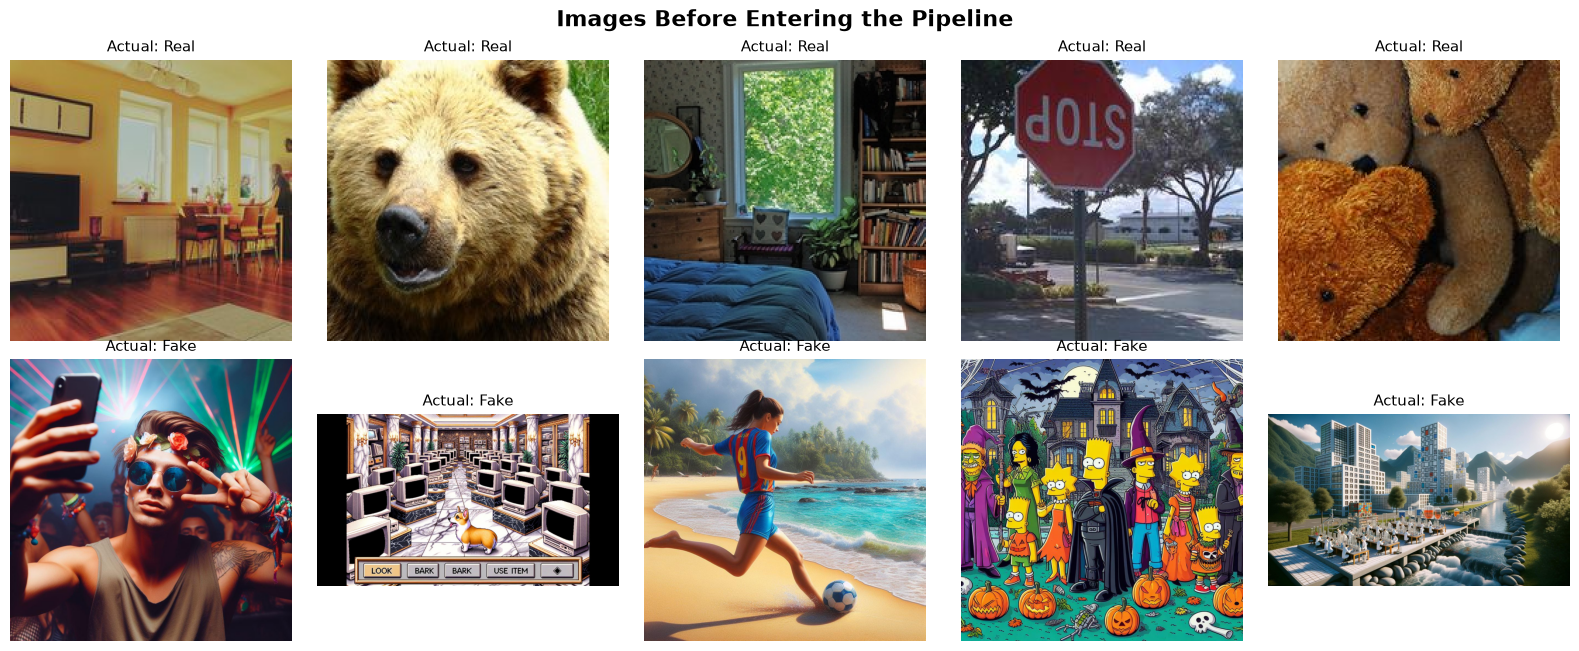

In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
LABELS = {
    "cocoval2017(real)": 0,
    "dalleadvanced(fake)": 1,
}
LABEL_NAMES = {0: "Real", 1: "Fake"}

paths = sorted(
    p.resolve() for p in IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    and any(
        folder.lower() in LABELS
        for folder in p.relative_to(IMAGE_DIR).parts[:-1]
    )
)

def label_from_folder(path):
    folders = [part.lower() for part in path.relative_to(IMAGE_DIR.resolve()).parts[:-1]]
    labels = []
    for folder in folders:
        if folder in LABELS:
            labels.append(LABELS[folder])
    return labels[0] if labels else None

results = pd.DataFrame({
    "path": [str(p) for p in paths],
    "relative_path": [str(p.relative_to(IMAGE_DIR.resolve())) for p in paths],
    "label": pd.array([label_from_folder(p) for p in paths], dtype="Int64"),
})

def show_image_gallery(frame, title, prediction_view=False, columns=5, images_per_label=5):
    gallery = pd.concat([
        frame.loc[frame.label == 0].head(images_per_label),
        frame.loc[frame.label == 1].head(images_per_label),
    ])
    rows = int(np.ceil(len(gallery) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3.2 * columns, 3.3 * rows))
    axes = np.atleast_1d(axes).reshape(-1)
    for axis, (_, row) in zip(axes, gallery.iterrows()):
        image, error = load_image_safe(row.path)
        if image is not None:
            axis.imshow(image)
            image.close()
        actual = LABEL_NAMES.get(row.label, "Unknown")
        if prediction_view:
            axis.set_title(
                f"Actual: {actual}\nPredict: {row.prediction_label}\nP(Fake): {row.final_probability:.3f}",
                fontsize=10,
            )
        else:
            axis.set_title(f"Actual: {actual}", fontsize=11)
        axis.axis("off")
    for axis in axes[len(gallery):]:
        axis.axis("off")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.tight_layout()
    plt.show()

print(f"Images: {len(results)} | Real: {(results.label == 0).sum()} | Fake: {(results.label == 1).sum()}")
show_image_gallery(results, "Images Before Entering the Pipeline")


## 3. Run the full prediction pipeline


In [3]:
def release_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        torch.mps.empty_cache()

def input_signature(image_paths):
    records = []
    for path in image_paths:
        path = Path(path).resolve()
        stat = path.stat()
        records.append(f"{path}|{stat.st_size}|{stat.st_mtime_ns}")
    return hashlib.sha256("\n".join(records).encode("utf-8")).hexdigest()[:16]

def score_paths(scorer, image_paths, description, cache_name, batch_size=BATCH_SIZE):
    run_cache_dir = CACHE_DIR / input_signature(image_paths)
    run_cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = run_cache_dir / f"{cache_name}.npy"
    done_path = run_cache_dir / f"{cache_name}.done.npy"

    cache_matches = False
    if cache_path.exists() and done_path.exists():
        probabilities = np.load(cache_path, mmap_mode="r+")
        done = np.load(done_path)
        cache_matches = len(probabilities) == len(image_paths) and len(done) == len(image_paths)

    if cache_matches:
        print(f"{description}: resumed {done.sum()}/{len(done)} cached scores")
    else:
        probabilities = np.lib.format.open_memmap(
            cache_path, mode="w+", dtype=np.float64, shape=(len(image_paths),)
        )
        probabilities[:] = np.nan
        done = np.zeros(len(image_paths), dtype=bool)
        np.save(done_path, done)

    for start in tqdm(range(0, len(image_paths), batch_size), desc=description, unit="batch"):
        stop = min(start + batch_size, len(image_paths))
        pending = [i for i in range(start, stop) if not done[i]]
        images, positions = [], []
        for position in pending:
            image, error = load_image_safe(image_paths[position])
            if image is not None:
                images.append(image)
                positions.append(position)
            else:
                print(f"Skipped unreadable image: {image_paths[position]} ({error})")
                done[position] = True
        if images:
            probabilities[positions] = scorer.score_checked(images)
            done[positions] = True
            for image in images:
                image.close()
        probabilities.flush()
        np.save(done_path, done)
    return np.asarray(probabilities).copy()

image_paths = [Path(path) for path in results.path]

community = get("community_forensics", device=str(DEVICE))
results["Community Forensics Pr"] = score_paths(
    community, image_paths, "1/3 Community Forensics", "community_forensics"
)
del community
release_memory()

dinov3_l = DINOv3Scorer(
    checkpoint=str(DINO_L_CHECKPOINT), device=str(DEVICE), n_crops=8, seed=RANDOM_SEED
)
results["DINOv3-L detector Pr"] = score_paths(
    dinov3_l, image_paths, "2/3 DINOv3-L", "dinov3_l", batch_size=2
)
del dinov3_l
release_memory()

dinov3_b_stacking = StackingScorer(
    checkpoint=str(STACKING_CHECKPOINT), device=str(DEVICE), n_crops=3, seed=RANDOM_SEED
)
results["DINOv3-B stacking detector Pr"] = score_paths(
    dinov3_b_stacking, image_paths, "3/3 DINOv3-B stacking",
    "dinov3_b_stacking", batch_size=4
)
del dinov3_b_stacking
release_memory()

fusion_input = results[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
results["final_probability"] = fusion_model.predict_proba(fusion_input)[:, 1]
results["prediction"] = (results.final_probability >= FINAL_THRESHOLD).astype(int)
results["prediction_label"] = results.prediction.map(LABEL_NAMES)
print("Pipeline complete.")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

1/3 Community Forensics: resumed 13841/13841 cached scores


1/3 Community Forensics:   0%|          | 0/1731 [00:00<?, ?batch/s]

2/3 DINOv3-L: resumed 13841/13841 cached scores


2/3 DINOv3-L:   0%|          | 0/6921 [00:00<?, ?batch/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

3/3 DINOv3-B stacking: resumed 13841/13841 cached scores


3/3 DINOv3-B stacking:   0%|          | 0/3461 [00:00<?, ?batch/s]

Pipeline complete.


## 4. Predictions compared with actual labels


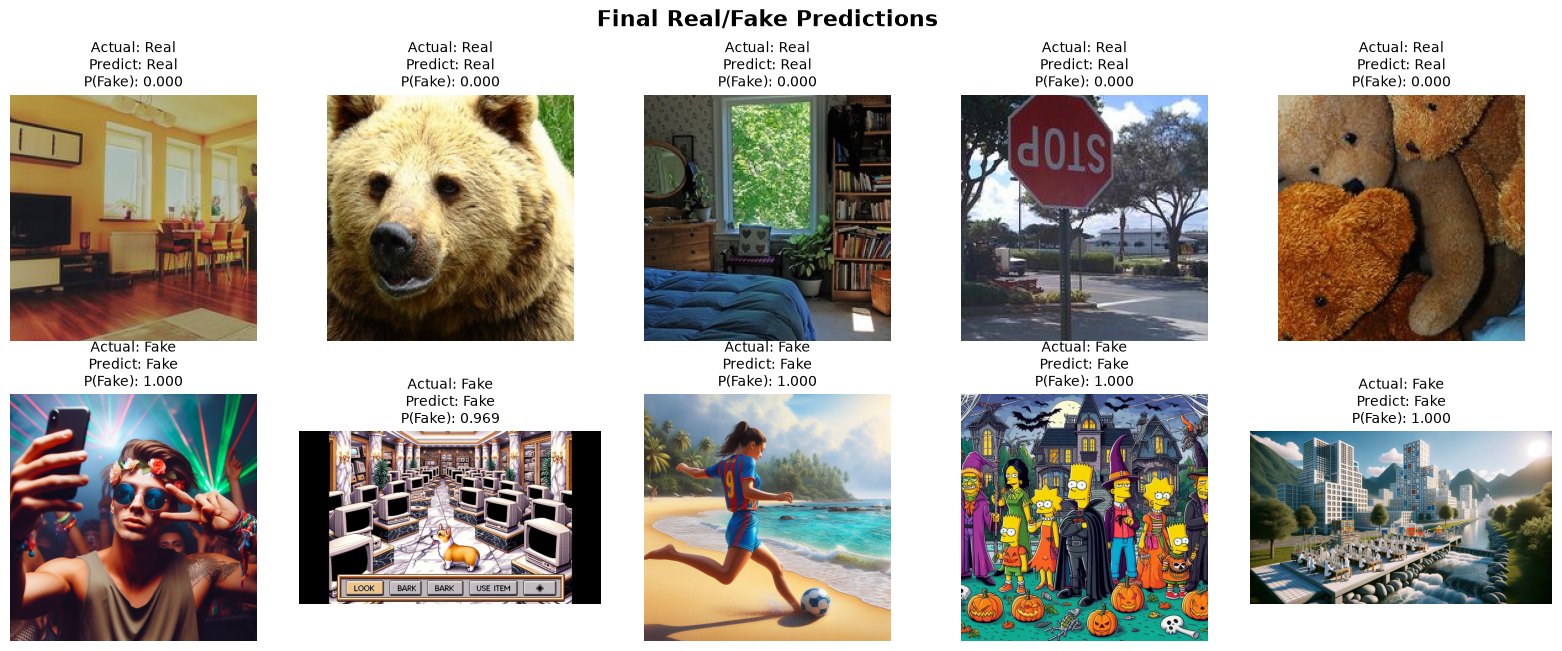

In [4]:
show_image_gallery(results, "Final Real/Fake Predictions", prediction_view=True)


## 5. Performance summary


In [5]:
y_true = results.label.to_numpy(dtype=int)
y_probability = results.final_probability.to_numpy(dtype=float)
y_prediction = results.prediction.to_numpy(dtype=int)
tn, fp, fn, tp = confusion_matrix(y_true, y_prediction, labels=[0, 1]).ravel()

summary = pd.DataFrame({"value": {
    "accuracy": accuracy_score(y_true, y_prediction),
    
    "precision": precision_score(y_true, y_prediction, zero_division=0),
    "recall_sensitivity": recall_score(y_true, y_prediction, zero_division=0),
    "specificity": tn / (tn + fp),
    "f1": f1_score(y_true, y_prediction, zero_division=0),

    "mcc": matthews_corrcoef(y_true, y_prediction),
    "roc_auc": roc_auc_score(y_true, y_probability),
}})

confusion_table = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Real", "Actual Fake"],
    columns=["Predicted Real", "Predicted Fake"],
)

display(summary)
display(confusion_table)


,value
accuracy,0.973268
precision,0.999058
recall_sensitivity,0.959064
specificity,0.998399
f1,0.978652
mcc,0.944351
roc_auc,0.999695


,Predicted Real,Predicted Fake
Actual Real,4990,8
Actual Fake,362,8481


## 6. Robustness evaluation

Every labelled image is evaluated once clean and under 14 deterministic transformations (15 versions total). Transformations are streamed in batches and cached for safe resumption.


In [6]:
TRANSFORM_SPECS = [
    ("JPEG Compression", "quality=90", "Social-media re-encode, messaging"),
    ("JPEG Compression", "quality=70", "Social-media re-encode, messaging"),
    ("JPEG Compression", "quality=50", "Social-media re-encode, messaging"),
    ("JPEG Compression", "quality=30", "Social-media re-encode, messaging"),
    ("Gaussian Blur", "sigma=0.5", "Out-of-focus"),
    ("Gaussian Blur", "sigma=1.0", "Out-of-focus"),
    ("Gaussian Blur", "sigma=2.0", "Out-of-focus"),
    ("Resize", "scale=0.5x then upscale", "Thumbnail generation"),
    ("Resize", "scale=0.25x then upscale", "Thumbnail generation"),
    ("Gaussian Noise", "sigma=0.02", "Low-light sensor noise"),
    ("Gaussian Noise", "sigma=0.05", "Low-light sensor noise"),
    ("Gaussian Noise", "sigma=0.10", "Low-light sensor noise"),
    ("Color Jitter", "brightness/contrast/saturation ±20%", "Filter apps, auto-enhance"),
    ("Center Crop", "crop=80%", "Profile-picture cropping, framing"),
]
transform_catalog = pd.DataFrame(
    TRANSFORM_SPECS, columns=["Transform", "Parameters", "Real-World Analog"]
)
display(transform_catalog)


,Transform,Parameters,Real-World Analog
0,JPEG Compression,quality=90,"Social-media re-encode, messaging"
1,JPEG Compression,quality=70,"Social-media re-encode, messaging"
2,JPEG Compression,quality=50,"Social-media re-encode, messaging"
3,JPEG Compression,quality=30,"Social-media re-encode, messaging"
4,Gaussian Blur,sigma=0.5,Out-of-focus
5,Gaussian Blur,sigma=1.0,Out-of-focus
6,Gaussian Blur,sigma=2.0,Out-of-focus
7,Resize,scale=0.5x then upscale,Thumbnail generation
8,Resize,scale=0.25x then upscale,Thumbnail generation
9,Gaussian Noise,sigma=0.02,Low-light sensor noise


Robustness subset: 13841 originals × 14 transforms = 193774 transformed evaluations


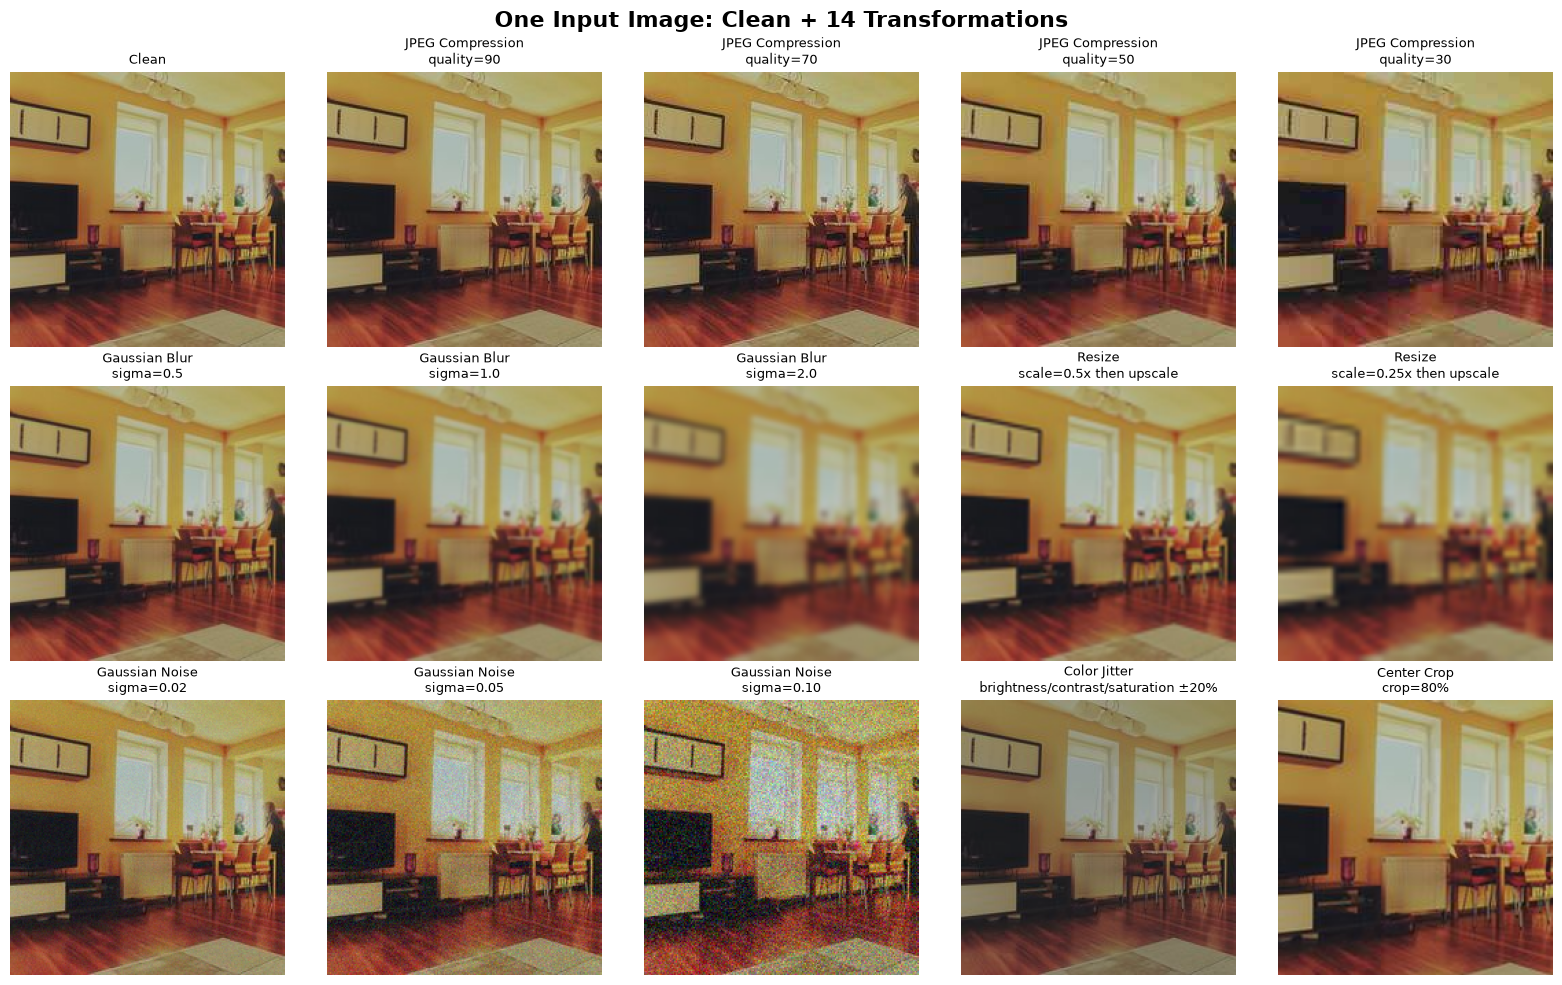

In [7]:
robustness_sources = results.loc[results.label.notna()].copy()

def jpeg_transform(image, quality):
    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    transformed = Image.open(buffer).convert("RGB")
    transformed.load()
    buffer.close()
    return transformed

def resize_transform(image, scale):
    width, height = image.size
    reduced_size = (max(1, round(width * scale)), max(1, round(height * scale)))
    reduced = image.resize(reduced_size, Image.Resampling.BICUBIC)
    return reduced.resize((width, height), Image.Resampling.BICUBIC)

def noise_transform(image, sigma, seed):
    rng = np.random.default_rng(seed)
    array = np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0
    noisy = np.clip(array + rng.normal(0, sigma, array.shape), 0, 1)
    return Image.fromarray(np.uint8(np.round(noisy * 255)), mode="RGB")

def jitter_transform(image, seed):
    rng = np.random.default_rng(seed)
    output = ImageEnhance.Brightness(image).enhance(rng.uniform(0.8, 1.2))
    output = ImageEnhance.Contrast(output).enhance(rng.uniform(0.8, 1.2))
    return ImageEnhance.Color(output).enhance(rng.uniform(0.8, 1.2))

def crop_transform(image, fraction=0.8):
    width, height = image.size
    crop_width, crop_height = round(width * fraction), round(height * fraction)
    left, top = (width - crop_width) // 2, (height - crop_height) // 2
    cropped = image.crop((left, top, left + crop_width, top + crop_height))
    return cropped.resize((width, height), Image.Resampling.BICUBIC)

def make_transformation(image, transform_name, parameters, source_path):
    if transform_name == "JPEG Compression":
        return jpeg_transform(image, int(parameters.split("=")[1]))
    if transform_name == "Gaussian Blur":
        return image.filter(ImageFilter.GaussianBlur(float(parameters.split("=")[1])))
    if transform_name == "Resize":
        return resize_transform(image, float(parameters.split("=")[1].split("x")[0]))
    if transform_name == "Gaussian Noise":
        sigma = float(parameters.split("=")[1])
        seed_text = "|".join([str(source_path), transform_name, parameters])
        seed = int(hashlib.sha256(seed_text.encode()).hexdigest()[:8], 16)
        return noise_transform(image, sigma, seed)
    if transform_name == "Color Jitter":
        seed_text = "|".join([str(source_path), transform_name, parameters])
        seed = int(hashlib.sha256(seed_text.encode()).hexdigest()[:8], 16)
        return jitter_transform(image, seed)
    return crop_transform(image)

robustness_images, robustness_records = [], []
for source_index, row in robustness_sources.head(1).iterrows():
    original, error = load_image_safe(row.path)
    if original is None:
        print("Skipped unreadable image:", row.path, error)
        continue
    original = original.convert("RGB")
    for transform_name, parameters, analog in TRANSFORM_SPECS:
        robustness_images.append(
            make_transformation(original, transform_name, parameters, row.path)
        )
        robustness_records.append({
            "source_index": source_index,
            "label": int(row.label),
            "Transform": transform_name,
            "Parameters": parameters,
            "Real-World Analog": analog,
        })
    original.close()

robustness_results = pd.DataFrame(robustness_records)
print(
    "Robustness subset:",
    len(robustness_sources), "originals ×", len(TRANSFORM_SPECS),
    "transforms =", len(robustness_sources) * len(TRANSFORM_SPECS), "transformed evaluations",
)

example_source = robustness_results.source_index.iloc[0]
positions = robustness_results.index[
    robustness_results.source_index == example_source
].tolist()
clean_example, _ = load_image_safe(robustness_sources.loc[example_source, "path"])
example_images = [clean_example] + [robustness_images[position] for position in positions]
example_titles = ["Clean"] + [
    robustness_results.loc[position, "Transform"] + "\n" +
    robustness_results.loc[position, "Parameters"]
    for position in positions
]

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for axis, image, title in zip(axes.reshape(-1), example_images, example_titles):
    axis.imshow(image)
    axis.set_title(title, fontsize=9)
    axis.axis("off")
fig.suptitle("One Input Image: Clean + 14 Transformations", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()
clean_example.close()


In [8]:
"""Disabled small-subset implementation; retained only for notebook history.
def score_image_objects(scorer, images, description, batch_size):
    probabilities = np.full(len(images), np.nan, dtype=float)
    for start in tqdm(range(0, len(images), batch_size), desc=description, unit="batch"):
        stop = min(start + batch_size, len(images))
        probabilities[start:stop] = scorer.score_checked(images[start:stop])
    return probabilities

community = get("community_forensics", device=str(DEVICE))
robustness_results["Community Forensics Pr"] = score_image_objects(
    community, robustness_images, "Robustness 1/3 Community Forensics", BATCH_SIZE
)
del community
release_memory()

dinov3_l = DINOv3Scorer(
    checkpoint=str(DINO_L_CHECKPOINT), device=str(DEVICE), n_crops=8, seed=RANDOM_SEED
)
robustness_results["DINOv3-L detector Pr"] = score_image_objects(
    dinov3_l, robustness_images, "Robustness 2/3 DINOv3-L", 2
)
del dinov3_l
release_memory()

dinov3_b_stacking = StackingScorer(
    checkpoint=str(STACKING_CHECKPOINT), device=str(DEVICE), n_crops=3, seed=RANDOM_SEED
)
robustness_results["DINOv3-B stacking detector Pr"] = score_image_objects(
    dinov3_b_stacking, robustness_images,
    "Robustness 3/3 DINOv3-B stacking", 4
)
del dinov3_b_stacking
release_memory()

fusion_input = robustness_results[FEATURE_COLUMNS].to_numpy(dtype=float)
robustness_results["final_probability"] = fusion_model.predict_proba(fusion_input)[:, 1]
robustness_results["prediction"] = (
    robustness_results.final_probability >= FINAL_THRESHOLD
).astype(int)

for transformed_image in robustness_images:
    transformed_image.close()
del robustness_images
release_memory()
print("Robustness scoring complete.")
"""


'Disabled small-subset implementation; retained only for notebook history.\ndef score_image_objects(scorer, images, description, batch_size):\n    probabilities = np.full(len(images), np.nan, dtype=float)\n    for start in tqdm(range(0, len(images), batch_size), desc=description, unit="batch"):\n        stop = min(start + batch_size, len(images))\n        probabilities[start:stop] = scorer.score_checked(images[start:stop])\n    return probabilities\n\ncommunity = get("community_forensics", device=str(DEVICE))\nrobustness_results["Community Forensics Pr"] = score_image_objects(\n    community, robustness_images, "Robustness 1/3 Community Forensics", BATCH_SIZE\n)\ndel community\nrelease_memory()\n\ndinov3_l = DINOv3Scorer(\n    checkpoint=str(DINO_L_CHECKPOINT), device=str(DEVICE), n_crops=8, seed=RANDOM_SEED\n)\nrobustness_results["DINOv3-L detector Pr"] = score_image_objects(\n    dinov3_l, robustness_images, "Robustness 2/3 DINOv3-L", 2\n)\ndel dinov3_l\nrelease_memory()\n\ndinov3_b_

In [9]:
from evaluation.robustness_all import run_all_image_robustness

detector_runs = [
    (
        "Community Forensics Pr",
        "community_forensics",
        lambda: get("community_forensics", device=str(DEVICE)),
        BATCH_SIZE,
    ),
    (
        "DINOv3-L detector Pr",
        "dinov3_l",
        lambda: DINOv3Scorer(
            checkpoint=str(DINO_L_CHECKPOINT),
            device=str(DEVICE),
            n_crops=8,
            seed=RANDOM_SEED,
        ),
        2,
    ),
    (
        "DINOv3-B stacking detector Pr",
        "dinov3_b_stacking",
        lambda: StackingScorer(
            checkpoint=str(STACKING_CHECKPOINT),
            device=str(DEVICE),
            n_crops=3,
            seed=RANDOM_SEED,
        ),
        4,
    ),
]

robustness_results = run_all_image_robustness(
    sources=robustness_sources,
    transform_specs=TRANSFORM_SPECS,
    make_transformation=make_transformation,
    detector_runs=detector_runs,
    feature_columns=FEATURE_COLUMNS,
    fusion_model=fusion_model,
    threshold=FINAL_THRESHOLD,
    cache_root=CACHE_DIR,
)
for transformed_image in robustness_images:
    transformed_image.close()
del robustness_images
release_memory()
print("Robustness scoring complete:", len(robustness_results), "evaluations")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Robustness 1/3 JPEG Compression quality=90:   0%|          | 0/1731 [00:00<?, ?batch/s]

Robustness 1/3 JPEG Compression quality=70:   0%|          | 0/1731 [00:00<?, ?batch/s]

Robustness 1/3 JPEG Compression quality=50:   0%|          | 0/1731 [00:00<?, ?batch/s]

Robustness 1/3 JPEG Compression quality=30:   0%|          | 0/1731 [00:00<?, ?batch/s]

...

Robustness 3/3 Gaussian Noise sigma=0.05:   0%|          | 0/3461 [00:00<?, ?batch/s]

Robustness 3/3 Gaussian Noise sigma=0.10:   0%|          | 0/3461 [00:00<?, ?batch/s]

Robustness 3/3 Color Jitter brightness/contrast/saturation ±20%:   0%|          | 0/3461 [00:00<?, ?batch/s]

Robustness 3/3 Center Crop crop=80%:   0%|          | 0/3461 [00:00<?, ?batch/s]

Robustness scoring complete: 193774 evaluations


In [10]:
METRIC_ORDER = [
    "accuracy", "precision", "recall_sensitivity",
    "specificity", "f1", "mcc", "roc_auc",
]

def calculate_presentation_metrics(frame):
    truth = frame.label.to_numpy(dtype=int)
    probability = frame.final_probability.to_numpy(dtype=float)
    prediction = frame.prediction.to_numpy(dtype=int)
    tn, fp, fn, tp = confusion_matrix(truth, prediction, labels=[0, 1]).ravel()
    values = {
        "accuracy": accuracy_score(truth, prediction),
        "precision": precision_score(truth, prediction, zero_division=0),
        "recall_sensitivity": recall_score(truth, prediction, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1": f1_score(truth, prediction, zero_division=0),
        "mcc": matthews_corrcoef(truth, prediction),
        "roc_auc": roc_auc_score(truth, probability),
    }
    matrix = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual Real", "Actual Fake"],
        columns=["Predicted Real", "Predicted Fake"],
    )
    return values, matrix

clean_subset = robustness_sources[
    ["label", "final_probability", "prediction"]
].copy()
clean_metrics, clean_confusion = calculate_presentation_metrics(clean_subset)

detail_rows = []
group_columns = ["Transform", "Parameters", "Real-World Analog"]
for group_key, group in robustness_results.groupby(group_columns, sort=False):
    values, _ = calculate_presentation_metrics(group)
    detail_rows.append(dict(zip(group_columns, group_key)) | values)

robustness_detail = pd.DataFrame(detail_rows)
transformed_mean = robustness_detail[METRIC_ORDER].mean().to_dict()
_, transformed_confusion = calculate_presentation_metrics(robustness_results)

clean_vs_transformed = pd.DataFrame({
    "Clean": clean_metrics,
    "Transformed Mean": transformed_mean,
}).loc[METRIC_ORDER]

print("Clean vs transformed robustness summary")
display(clean_vs_transformed.round(6))
print("Clean summary")
display(pd.DataFrame({"value": clean_metrics}).loc[METRIC_ORDER].round(6))
print("Clean confusion matrix")
display(clean_confusion)
print("Transformed mean summary")
display(pd.DataFrame({"value": transformed_mean}).loc[METRIC_ORDER].round(6))
print("Overall transformed confusion matrix (14 conditions pooled)")
display(transformed_confusion)
print("Detailed performance for every transformation setting")
display(
    robustness_detail[
        ["Transform", "Parameters", "Real-World Analog", *METRIC_ORDER]
    ].round(6)
)


Clean vs transformed robustness summary


,Clean,Transformed Mean
accuracy,0.973268,0.946319
precision,0.999058,0.991267
recall_sensitivity,0.959064,0.924622
specificity,0.998399,0.984708
f1,0.978652,0.954985
mcc,0.944351,0.895420
roc_auc,0.999695,0.996218


Clean summary


,value
accuracy,0.973268
precision,0.999058
recall_sensitivity,0.959064
specificity,0.998399
f1,0.978652
mcc,0.944351
roc_auc,0.999695


Clean confusion matrix


...

,value
accuracy,0.946319
precision,0.991267
recall_sensitivity,0.924622
specificity,0.984708
f1,0.954985
mcc,0.895420
roc_auc,0.996218


Overall transformed confusion matrix (14 conditions pooled)


,Predicted Real,Predicted Fake
Actual Real,68902,1070
Actual Fake,9332,114470


Detailed performance for every transformation setting


,Transform,Parameters,Real-World Analog,accuracy,precision,recall_sensitivity,specificity,f1,mcc,roc_auc
0,JPEG Compression,quality=90,"Social-media re-encode, messaging",0.974279,0.999059,0.960647,0.998399,0.979477,0.946372,0.999703
1,JPEG Compression,quality=70,"Social-media re-encode, messaging",0.961563,0.998680,0.941083,0.997799,0.969027,0.921322,0.999580
2,JPEG Compression,quality=50,"Social-media re-encode, messaging",0.954844,0.998665,0.930567,0.997799,0.963414,0.908491,0.999405
3,JPEG Compression,quality=30,"Social-media re-encode, messaging",0.909472,0.998293,0.859776,0.997399,0.923871,0.827626,0.998565
4,Gaussian Blur,sigma=0.5,Out-of-focus,0.975580,0.999061,0.962682,0.998399,0.980534,0.948980,0.999534
5,Gaussian Blur,sigma=1.0,Out-of-focus,0.973557,0.994516,0.963926,0.990596,0.978982,0.944198,0.998173
6,Gaussian Blur,sigma=2.0,Out-of-focus,0.947258,0.959036,0.958385,0.927571,0.958710,0.885725,0.983326
7,Resize,scale=0.5x then upscale,Thumbnail generation,0.973485,0.997184,0.961212,0.995198,0.978868,0.944468,0.999149
8,Resize,scale=0.25x then upscale,Thumbnail generation,0.941839,0.944580,0.965623,0.899760,0.954985,0.873285,0.977224
9,Gaussian Noise,sigma=0.02,Low-light sensor noise,0.969872,0.997403,0.955332,0.995598,0.975914,0.937297,0.999368
